# Chapter 14 Lab: Bounded Autonomous Agents and Systemic Risk

**Runtime:** 3–4 minutes · **Difficulty:** advanced · **Credentials:** none

The model proposes a typed intent; a deterministic gate decides whether a fictional paper
order is admissible. The second half simulates correlated agents and shows how common
models can create herding and unstable interaction dynamics.


[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/14_bounded_autonomous_agents.ipynb) · [View source on GitHub](https://github.com/PacktPublishing/LLMs-in-Finance/blob/main/notebooks/14_bounded_autonomous_agents.ipynb)

The next cell is inert outside Google Colab. In Colab it retrieves the official repository and installs the local package before the lab runs.


In [1]:
# Google Colab bootstrap — inert during local and CI execution.
import os as _os
from pathlib import Path as _Path
import subprocess as _subprocess
import sys as _sys

try:
    import google.colab as _google_colab  # type: ignore[import-not-found]
except ImportError:
    _in_colab = False
else:
    _in_colab = True

if _in_colab:
    _repo = _Path("/content/LLMs-in-Finance")
    if _repo.exists() and not (_repo / ".git").is_dir():
        raise RuntimeError(f"Refusing to overwrite non-repository path: {_repo}")
    if _repo.exists():
        _subprocess.run(
            ["git", "-C", str(_repo), "fetch", "--depth", "1", "origin", "main"],
            check=True,
        )
        _subprocess.run(
            ["git", "-C", str(_repo), "checkout", "--detach", "FETCH_HEAD"],
            check=True,
        )
    else:
        _subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                "main",
                "https://github.com/PacktPublishing/LLMs-in-Finance.git",
                str(_repo),
            ],
            check=True,
        )
    _subprocess.run(
        [_sys.executable, "-m", "pip", "install", "-q", "-e", str(_repo)],
        check=True,
    )
    _os.chdir(_repo)


## Learning objectives

- validate structured trade intents;
- apply evidence, notional, and mandate limits outside the model;
- preserve evidence-to-intent-to-paper-fill lineage;
- measure herding under common-model dependence; and
- connect interaction strength to spectral stability.


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from finllm_lab import TradeIntent, canonical_hash, seed_everything
from finllm_lab.market import herding_index, herding_null_baseline, spectral_abscissa
from finllm_lab.plotting import COLORS, finish, set_finance_theme

set_finance_theme()
rng = seed_everything(1414)


## 1. Typed proposal and deterministic risk gate


In [3]:
def risk_gate(intent: TradeIntent, price: float, mandate: dict) -> dict:
    try:
        intent.validate()
    except ValueError as exc:
        return {"status": "reject", "reason": str(exc)}
    if intent.symbol not in mandate["allowed_symbols"]:
        return {"status": "reject", "reason": "symbol is outside the mandate"}
    if intent.side == "HOLD":
        return {"status": "no_action", "reason": "HOLD creates no order"}
    valuation_price = intent.limit_price if intent.limit_price is not None else price
    notional = intent.quantity * valuation_price
    if intent.side == "SELL" and not mandate["shorting_allowed"]:
        return {"status": "reject", "reason": "short selling is prohibited"}
    if notional > mandate["max_order_notional"]:
        return {"status": "escalate", "reason": "order exceeds delegated notional"}
    if intent.confidence < mandate["minimum_confidence"]:
        return {"status": "reject", "reason": "confidence is below the declared floor"}
    return {
        "status": "allow_paper_only",
        "reason": "within mandate",
        "sanitized_order": {
            "symbol": intent.symbol,
            "side": intent.side,
            "quantity": intent.quantity,
            "notional": notional,
        },
    }

mandate = {
    "allowed_symbols": {"ACME", "NIMB", "ORBT", "VELA"},
    "shorting_allowed": False,
    "max_order_notional": 50_000,
    "minimum_confidence": 0.65,
}
intents = [
    TradeIntent("ACME", "BUY", 200, 102.0, "Fictional earnings follow-up", ("ev-001",), 0.78),
    TradeIntent("ACME", "BUY", 900, 102.0, "Fictional earnings follow-up", ("ev-001",), 0.81),
    TradeIntent("NIMB", "SELL", 100, None, "Risk concern", ("ev-002",), 0.74),
    TradeIntent("ORBT", "HOLD", 0, None, "Evidence is mixed", tuple(), 0.55),
]
intent_results = pd.DataFrame(
    [
        {
            "symbol": intent.symbol,
            "side": intent.side,
            "quantity": intent.quantity,
            **risk_gate(intent, price=102.0, mandate=mandate),
        }
        for intent in intents
    ]
)
intent_results[["symbol", "side", "quantity", "status", "reason"]]


,symbol,side,quantity,status,reason
0,ACME,BUY,200,allow_paper_only,within mandate
1,ACME,BUY,900,escalate,order exceeds delegated notional
2,NIMB,SELL,100,reject,short selling is prohibited
3,ORBT,HOLD,0,no_action,HOLD creates no order


## 2. Evidence-to-paper-fill lineage


In [4]:
approved_intent = intents[0]
gate_result = risk_gate(approved_intent, 102.0, mandate)
paper_fill = {
    "venue": "fictional-paper-broker",
    "fill_price": 102.08,
    "quantity": gate_result["sanitized_order"]["quantity"],
    "status": "simulated",
}
lineage = {
    "evidence_ids": approved_intent.evidence_ids,
    "intent_hash": canonical_hash(approved_intent),
    "gate_hash": canonical_hash(gate_result),
    "paper_fill_hash": canonical_hash(paper_fill),
    "live_execution_enabled": False,
}
lineage


{'evidence_ids': ('ev-001',),
 'gate_hash': '98ebf3a53af23a7bea3b8eb9806a8c094f98b91d543d4efff4f080b96865e89d',
 'intent_hash': '6642634e1f2882cedf63aa5a5135fbef499fab062b30df760aa96948de115f55',
 'live_execution_enabled': False,
 'paper_fill_hash': 'ec6c41241286755aa30791fdbd458dd351ce0c3209610bb97703bdab7ed3d49b'}

## 3. Herding from shared models

Each agent combines a common signal with idiosyncratic noise. Higher common dependence
produces more one-sided actions even though agents never communicate.


In [5]:
n_agents = 60
correlations = np.linspace(0, 0.95, 12)
herding_rows = []
for rho in correlations:
    simulations = []
    for _ in range(500):
        common = rng.normal()
        individual = rng.normal(size=n_agents)
        scores = np.sqrt(rho) * common + np.sqrt(1 - rho) * individual
        actions = np.sign(scores)
        simulations.append(herding_index(actions))
    herding_rows.append(
        {
            "common_dependence": rho,
            "mean_herding": np.mean(simulations),
            "p95_herding": np.quantile(simulations, 0.95),
        }
    )
herding = pd.DataFrame(herding_rows)
null_baseline = herding_null_baseline(n_agents)
herding["excess_over_independent_baseline"] = herding["mean_herding"] - null_baseline
herding.round(3)


,common_dependence,mean_herding,p95_herding,excess_over_independent_baseline
0,0.000,0.102,0.233,-0.001
1,0.086,0.221,0.500,0.118
2,0.173,0.303,0.733,0.200
3,0.259,0.334,0.767,0.231
4,0.345,0.401,0.868,0.298
5,0.432,0.459,0.933,0.356
6,0.518,0.532,1.000,0.429
7,0.605,0.563,1.000,0.460
8,0.691,0.643,1.000,0.540
9,0.777,0.700,1.000,0.597


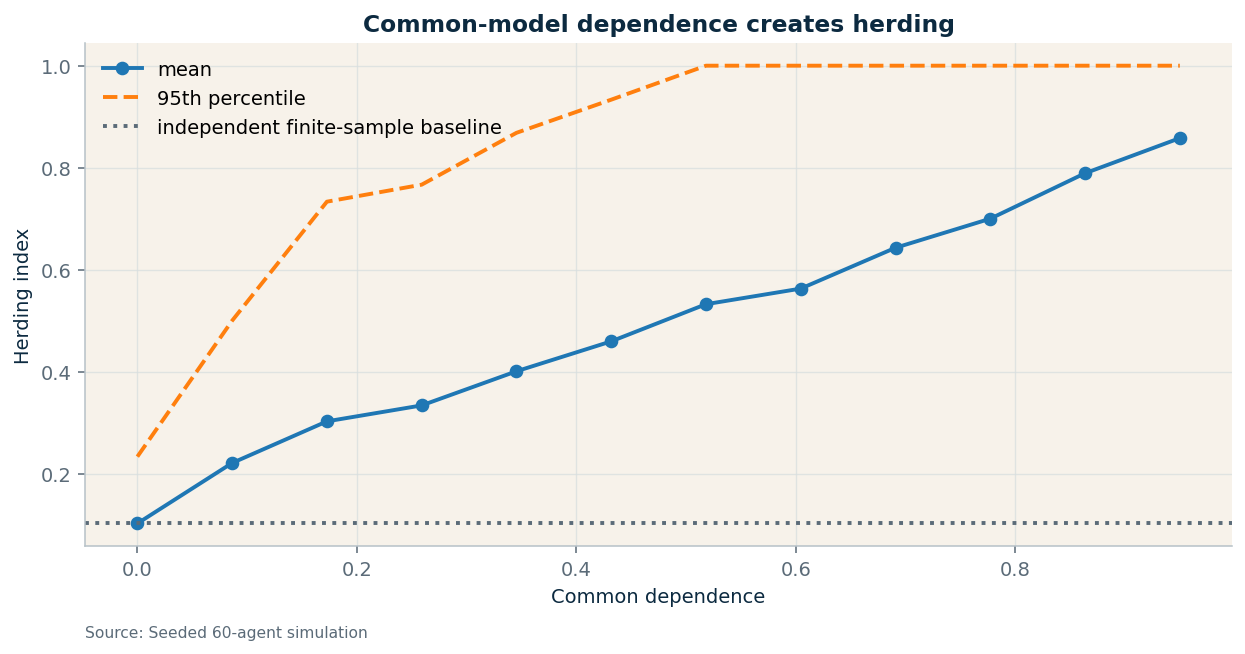

In [6]:
fig, ax = plt.subplots()
ax.plot(herding["common_dependence"], herding["mean_herding"], marker="o", label="mean")
ax.plot(herding["common_dependence"], herding["p95_herding"], linestyle="--", label="95th percentile")
ax.axhline(
    null_baseline,
    color=COLORS["slate"],
    linestyle=":",
    label="independent finite-sample baseline",
)
ax.set(title="Common-model dependence creates herding", xlabel="Common dependence", ylabel="Herding index")
ax.legend()
finish(ax, "Seeded 60-agent simulation")
plt.tight_layout()


## 4. Local spectral stability

We linearize a stylized interaction system. Self-damping is negative; positive coupling
propagates agent actions. The equilibrium becomes locally unstable when the spectral
abscissa crosses zero.


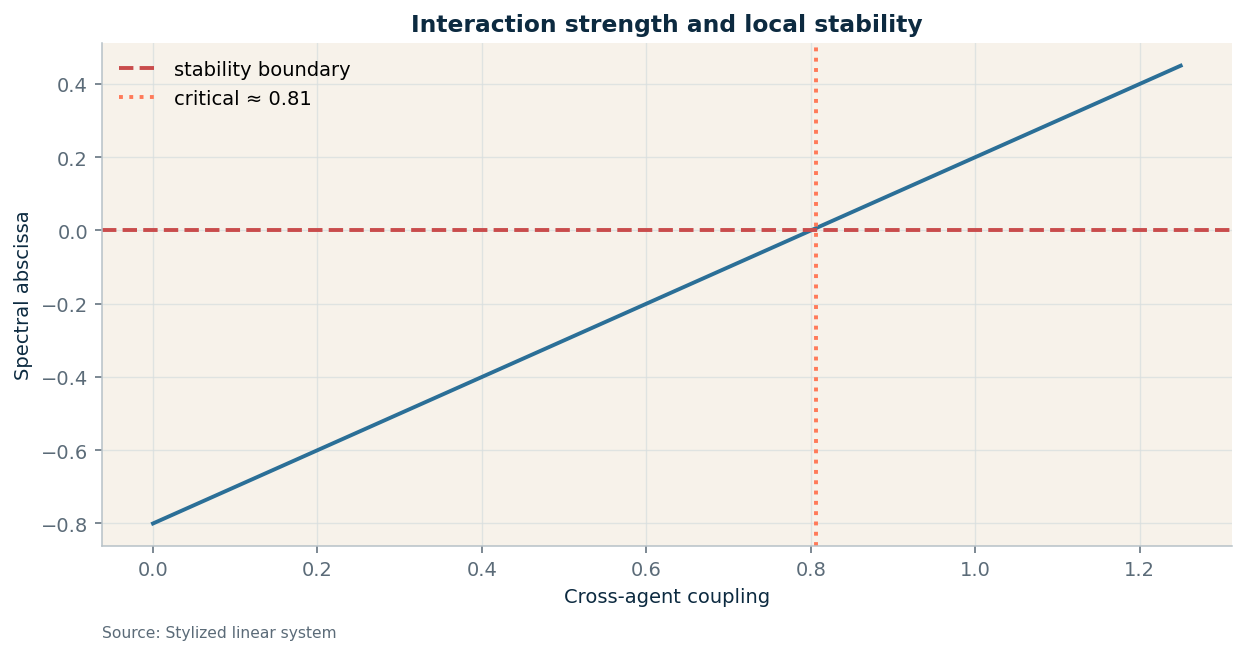

In [7]:
n = 20
self_damping = 0.80
couplings = np.linspace(0, 1.25, 80)
stability = []
for coupling in couplings:
    interaction = np.full((n, n), coupling / (n - 1))
    np.fill_diagonal(interaction, -self_damping)
    stability.append(spectral_abscissa(interaction))
stability = np.array(stability)
crossings = np.flatnonzero(stability >= 0)
critical = couplings[crossings[0]] if len(crossings) else np.nan
fig, ax = plt.subplots()
ax.plot(couplings, stability, color=COLORS["blue"])
ax.axhline(0, color=COLORS["red"], linestyle="--", label="stability boundary")
if np.isfinite(critical):
    ax.axvline(
        critical,
        color=COLORS["coral"],
        linestyle=":",
        label=f"critical ≈ {critical:.2f}",
    )
ax.set(title="Interaction strength and local stability", xlabel="Cross-agent coupling", ylabel="Spectral abscissa")
ax.legend()
finish(ax, "Stylized linear system")
plt.tight_layout()


## 5. Circuit-breaker policy


In [8]:
events = pd.DataFrame(
    [
        {"time": "10:00", "herding": 0.22, "concentration": 0.30, "spectral_risk": -0.35},
        {"time": "10:05", "herding": 0.51, "concentration": 0.57, "spectral_risk": -0.08},
        {"time": "10:10", "herding": 0.79, "concentration": 0.72, "spectral_risk": 0.04},
    ]
)
events["intervention"] = np.select(
    [
        events["spectral_risk"] >= 0,
        (events["herding"] > 0.65) | (events["concentration"] > 0.65),
        (events["herding"] > 0.45) | (events["concentration"] > 0.50),
    ],
    ["kill switch + human escalation", "throttle + targeted stress", "increase surveillance"],
    default="monitor",
)
events


,time,herding,concentration,spectral_risk,intervention
0,10:00,0.22,0.30,-0.35,monitor
1,10:05,0.51,0.57,-0.08,increase surveillance
2,10:10,0.79,0.72,0.04,kill switch + human escalation


## Takeaways

- A typed intent constrains shape; a risk gate constrains authority.
- Paper fills keep the teaching loop safe and replayable.
- Shared vendors and models can synchronize agents without explicit collusion.
- A finite independent population has nonzero expected herding, so monitoring needs a
  null baseline rather than a zero benchmark.
- System-level monitoring needs herding, concentration, liquidity, and interaction stress.

**Challenge:** add heterogeneous capital constraints and a price-impact feedback loop,
then compare agent-level safety with system-level stability.
